In [19]:
#import
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
# ------------------------------
# HYPERPARAMETERS & SETTINGS
# ------------------------------

# Model & Training Config
FEATURES = [
    "packet_size", "src_port", "dst_port", "ttl", "time_since_last_pkt", "TCP", "UDP", "ICMP"
]
HIDDEN_LAYERS = [128, 64, 32]
ACTIVATION = nn.ReLU
DROPOUT = 0.1
LOSS_FN = nn.MSELoss
OPTIMIZER_FN = optim.Adam
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0
EPOCHS = 6000
BATCH_SIZE = 32
SEED = 42

# Set seeds for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)



/Users/jaytlinaskew/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128246 (\N{ANTENNA WITH BARS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


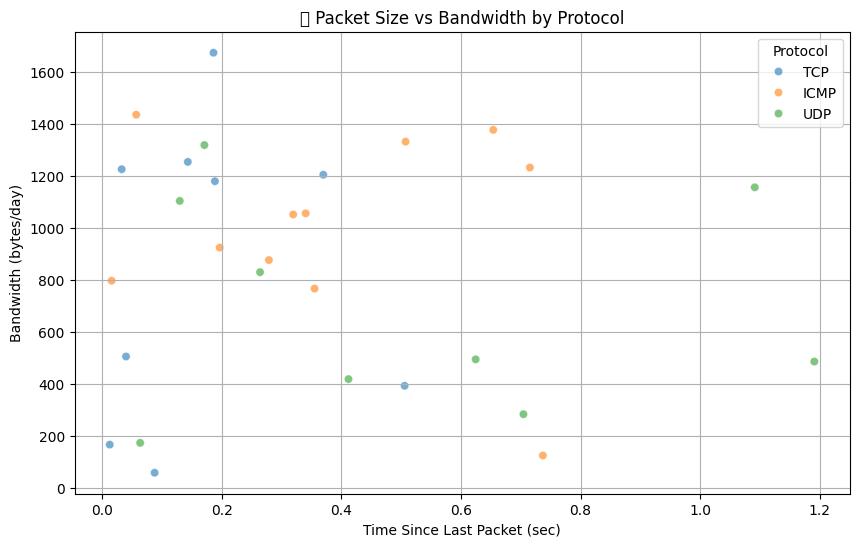

/var/folders/w0/j_6p0ljx1ydcv_rfg52l58s40000gn/T/ipykernel_59237/2898185654.py:61: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/jaytlinaskew/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


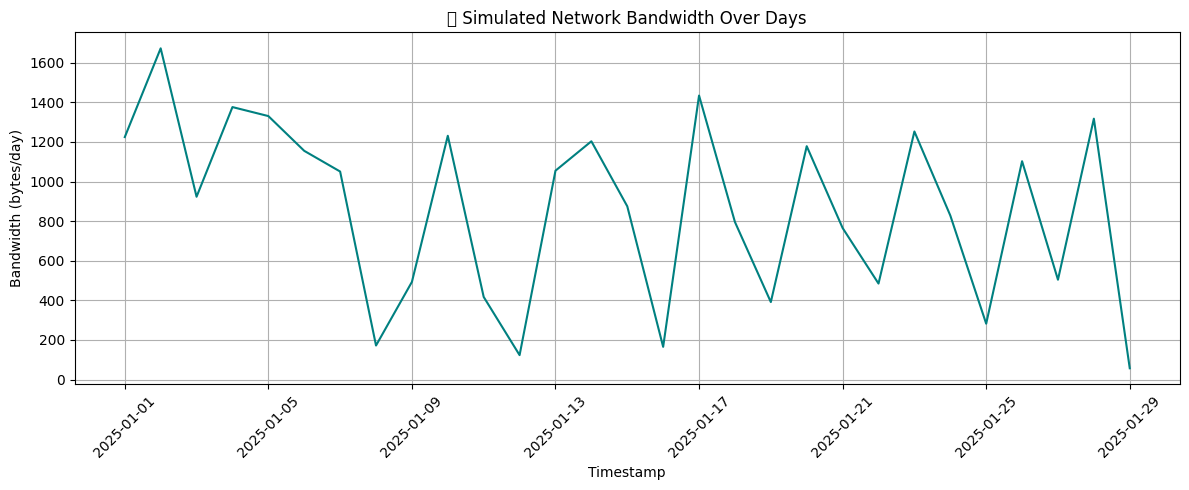

In [21]:
# ----------------------------
# Data Simulation Over Days
# ----------------------------
N_SAMPLES = 30  # simulate data for 30 days
timestamps = pd.date_range(start="2025-01-01", periods=N_SAMPLES, freq="D")
packet_size = np.random.randint(40, 1501, size=N_SAMPLES)
protocols = np.random.choice(["TCP", "UDP", "ICMP"], size=N_SAMPLES)
src_port = np.random.randint(0, 65536, size=N_SAMPLES)
dst_port = np.random.randint(0, 65536, size=N_SAMPLES)
ttl = np.random.randint(1, 256, size=N_SAMPLES)
# For a daily dataset, you might reconsider the scale,
# but we'll use the exponential distribution as a placeholder.
time_since_last_pkt = np.random.exponential(scale=0.5, size=N_SAMPLES)

# Target: next day’s bandwidth
bandwidth = packet_size * (1 + np.random.normal(0, 0.1, size=N_SAMPLES))

df = pd.DataFrame({
    "timestamp": timestamps,
    "packet_size": packet_size,
    "protocol": protocols,
    "src_port": src_port,
    "dst_port": dst_port,
    "ttl": ttl,
    "time_since_last_pkt": time_since_last_pkt,
    "bandwidth": bandwidth
})

# Shift target to make it a time series (next day's bandwidth) and drop the last row (NaN)
df["target_bandwidth"] = df["bandwidth"].shift(-1)
df.dropna(inplace=True)

# Preserve the original protocol for visualization
df["protocol_orig"] = df["protocol"]

# One-hot encode protocol and drop the original protocol column
protocol_dummies = pd.get_dummies(df["protocol"])
df = pd.concat([df.drop("protocol", axis=1), protocol_dummies], axis=1)

# ----------------------------
# Scatterplot Visualization
# ----------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="time_since_last_pkt", y="bandwidth", hue="protocol_orig", alpha=0.6)
plt.title("📶 Packet Size vs Bandwidth by Protocol")
plt.xlabel("Time Since Last Packet (sec)")
plt.ylabel("Bandwidth (bytes/day)")
plt.grid(True)
plt.legend(title="Protocol")
plt.show()

# ----------------------------
# Time Series Visualization
# ----------------------------
plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"].values, df["bandwidth"].values, label="Bandwidth", color="teal")
plt.title("📡 Simulated Network Bandwidth Over Days")
plt.xlabel("Timestamp")
plt.ylabel("Bandwidth (bytes/day)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()


In [22]:
# ----------------------------
# Preprocessing
# ----------------------------
scaler = MinMaxScaler()
X = scaler.fit_transform(df[FEATURES])
y = df["target_bandwidth"].values.reshape(-1, 1)

X_tensor = torch.tensor(X, dtype=torch.float32) # convert to tensor
y_tensor = torch.tensor(y, dtype=torch.float32)# convert to tensor

dataset = TensorDataset(X_tensor, y_tensor) # create dataset
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True) # create dataloader to shuffle data and create batches

In [23]:
# ----------------------------
# Customizable MLP Model
# ----------------------------
class NetTrafficRegressor(nn.Module): # create a class for the model
    def __init__(self, input_dim, hidden_dims, activation, dropout):
        super().__init__()
        layers = [] # create a list to store the layers
        dims = [input_dim] + hidden_dims # create a list of dimensions for the layers
        for i in range(len(dims) - 1): # loop through the dimensions to create the layers
            layers.append(nn.Linear(dims[i], dims[i + 1])) # add a linear layer
            layers.append(activation()) # add the activation function after the linear layer for non-linearity
            if dropout > 0: # add dropout if the dropout rate is greater than 0 to prevent overfitting
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], 1))
        self.net = nn.Sequential(*layers) # create the model as a sequential model

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # check if cuda is available and use it if it is available otherwise use cpu
model = NetTrafficRegressor(
    input_dim=len(FEATURES), # input dimension is the number of features
    hidden_dims=HIDDEN_LAYERS, # hidden layers are the hidden layers specified in the hyperparameters
    activation=ACTIVATION, # activation function is the activation function specified in the hyperparameters
    dropout=DROPOUT # dropout rate is the dropout rate specified in the hyperparameters
).to(device)

In [24]:
model

NetTrafficRegressor(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [25]:
# ----------------------------
# Loss & Optimizer
# ----------------------------
loss_fn = LOSS_FN() # create the loss function using the loss function specified in the hyperparameters
optimizer = OPTIMIZER_FN(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY) # create the optimizer using the optimizer specified in the hyperparameters

Epoch 000 | Train Loss: 888573.8125 | Test Loss: 888536.1250
Epoch 100 | Train Loss: 553398.8125 | Test Loss: 545835.2500
Epoch 200 | Train Loss: 206504.0625 | Test Loss: 175209.6250
Epoch 300 | Train Loss: 141953.1562 | Test Loss: 149972.2656
Epoch 400 | Train Loss: 178149.7188 | Test Loss: 132035.4062
Epoch 500 | Train Loss: 153760.8438 | Test Loss: 117660.9141
Epoch 600 | Train Loss: 95197.1406 | Test Loss: 106331.5547
Epoch 700 | Train Loss: 117017.4453 | Test Loss: 97937.3672
Epoch 800 | Train Loss: 85457.9531 | Test Loss: 92126.7734
Epoch 900 | Train Loss: 97741.5312 | Test Loss: 87488.2422
Epoch 1000 | Train Loss: 92845.5234 | Test Loss: 83779.0469
Epoch 1100 | Train Loss: 91173.9531 | Test Loss: 78291.4922
Epoch 1200 | Train Loss: 88108.7812 | Test Loss: 73969.2969
Epoch 1300 | Train Loss: 66711.0312 | Test Loss: 69349.7188
Epoch 1400 | Train Loss: 76164.5078 | Test Loss: 64432.3750
Epoch 1500 | Train Loss: 62365.1133 | Test Loss: 59385.0430
Epoch 1600 | Train Loss: 67656.2969 

/Users/jaytlinaskew/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


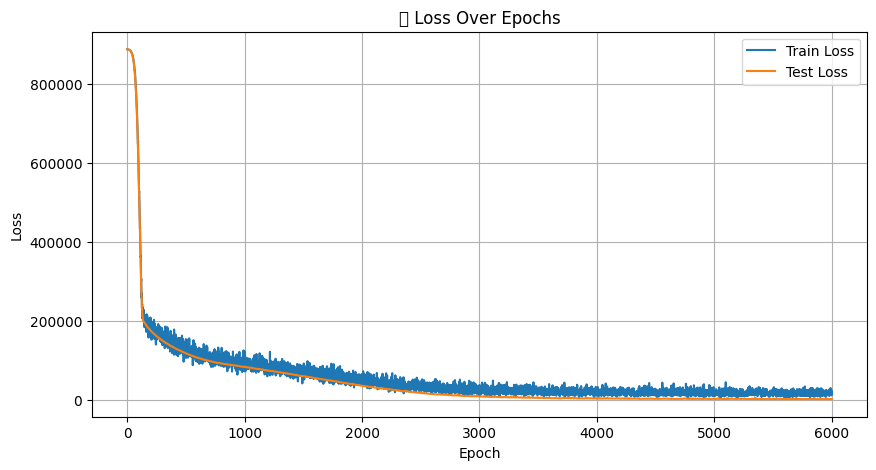

In [26]:
# ----------------------------
# Training Loop + Evaluation
# ----------------------------

train_losses = [] # create a list to store the training losses
test_losses = [] # create a list to store the test losses

for epoch in range(EPOCHS): # loop through the epochs for training the model specified in the hyperparameters
    model.train()
    running_loss = 0.0 # initialize the running loss to 0 for each epoch to calculate the average loss
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device) # move the data to the device (cuda or cpu)
        preds = model(xb)
        loss = loss_fn(preds, yb)
        optimizer.zero_grad() # zero the gradients to prevent accumulation of gradients
        loss.backward() # backpropagate the loss to calculate the gradients of the model parameters
        optimizer.step() # update the model parameters using the optimizer
        running_loss += loss.item() # add the loss to the running loss

    # Average train loss
    avg_train_loss = running_loss / len(loader)
    train_losses.append(avg_train_loss)

    # 🔍 Evaluate on full dataset (or you could use a test loader)
    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_tensor.to(device))
        test_loss = loss_fn(y_pred_test.cpu(), y_tensor).item()
        test_losses.append(test_loss)

    # 🖨️ Logging
    if epoch % 100 == 0 or epoch == EPOCHS - 1: # print the loss every 20 epochs
        print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss:.4f}")

# ----------------------------
# Plot Loss Curve
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("📉 Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [29]:
# ----------------------------
# Evaluation
# ----------------------------
model.eval()
with torch.no_grad(): # turn off gradient tracking for evaluation to save memory and computation time
    y_pred = model(X_tensor.to(device)).cpu().numpy() # predict the target values using the model
    y_true = y_tensor.cpu().numpy() # get the true target values from the tensor

import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=df["timestamp"][:200], y=y_true[:200].flatten(), mode='lines', name='True', opacity=0.7))
fig.add_trace(go.Scatter(x=df["timestamp"][:200], y=y_pred[:200].flatten(), mode='lines', name='Predicted', opacity=0.7))

fig.update_layout(
    title="📊 Bandwidth Prediction (Next Step)",
    xaxis_title="Date",
    yaxis_title="Bandwidth (bytes/sec)",
    legend_title="Legend",
    template="plotly_white"
)

fig.show()


/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

